In [1]:
# [Cell 1] Imports and Publication Styling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic styling for publication-ready plots
plt.style.use('default')
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300 # High resolution for papers

In [2]:
# [Cell 2] Model Validation Table
data = {
    'Model Architecture': [
        '1. Train from Scratch', 
        '2. Base MPNN (No RDKit)', 
        '3. Random Split (Data Leakage)', 
        '4. Single Model (No Ensemble)', 
        '5. Final v6 Model (Ensemble + Scaffold)'
    ],
    'ROC-AUC': ['0.8065 ± 0.0794', '0.7876 ± 0.0817', '0.8750 ± 0.0405', '0.7682', '0.8221 ± 0.0509'],
    'PRC-AUC': ['0.7584 ± 0.0988', '0.7340 ± 0.1168', '0.8321 ± 0.0818', '0.6958', '0.7668 ± 0.0822']
}

df_ablation = pd.DataFrame(data)

# Display the table cleanly
display(df_ablation.style.set_caption("Table 1: Chemprop Model Ablation and Validation Metrics")
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]))

,Model Architecture,ROC-AUC,PRC-AUC
0,1. Train from Scratch,0.8065 ± 0.0794,0.7584 ± 0.0988
1,2. Base MPNN (No RDKit),0.7876 ± 0.0817,0.7340 ± 0.1168
2,3. Random Split (Data Leakage),0.8750 ± 0.0405,0.8321 ± 0.0818
3,4. Single Model (No Ensemble),0.7682,0.6958
4,5. Final v6 Model (Ensemble + Scaffold),0.8221 ± 0.0509,0.7668 ± 0.0822


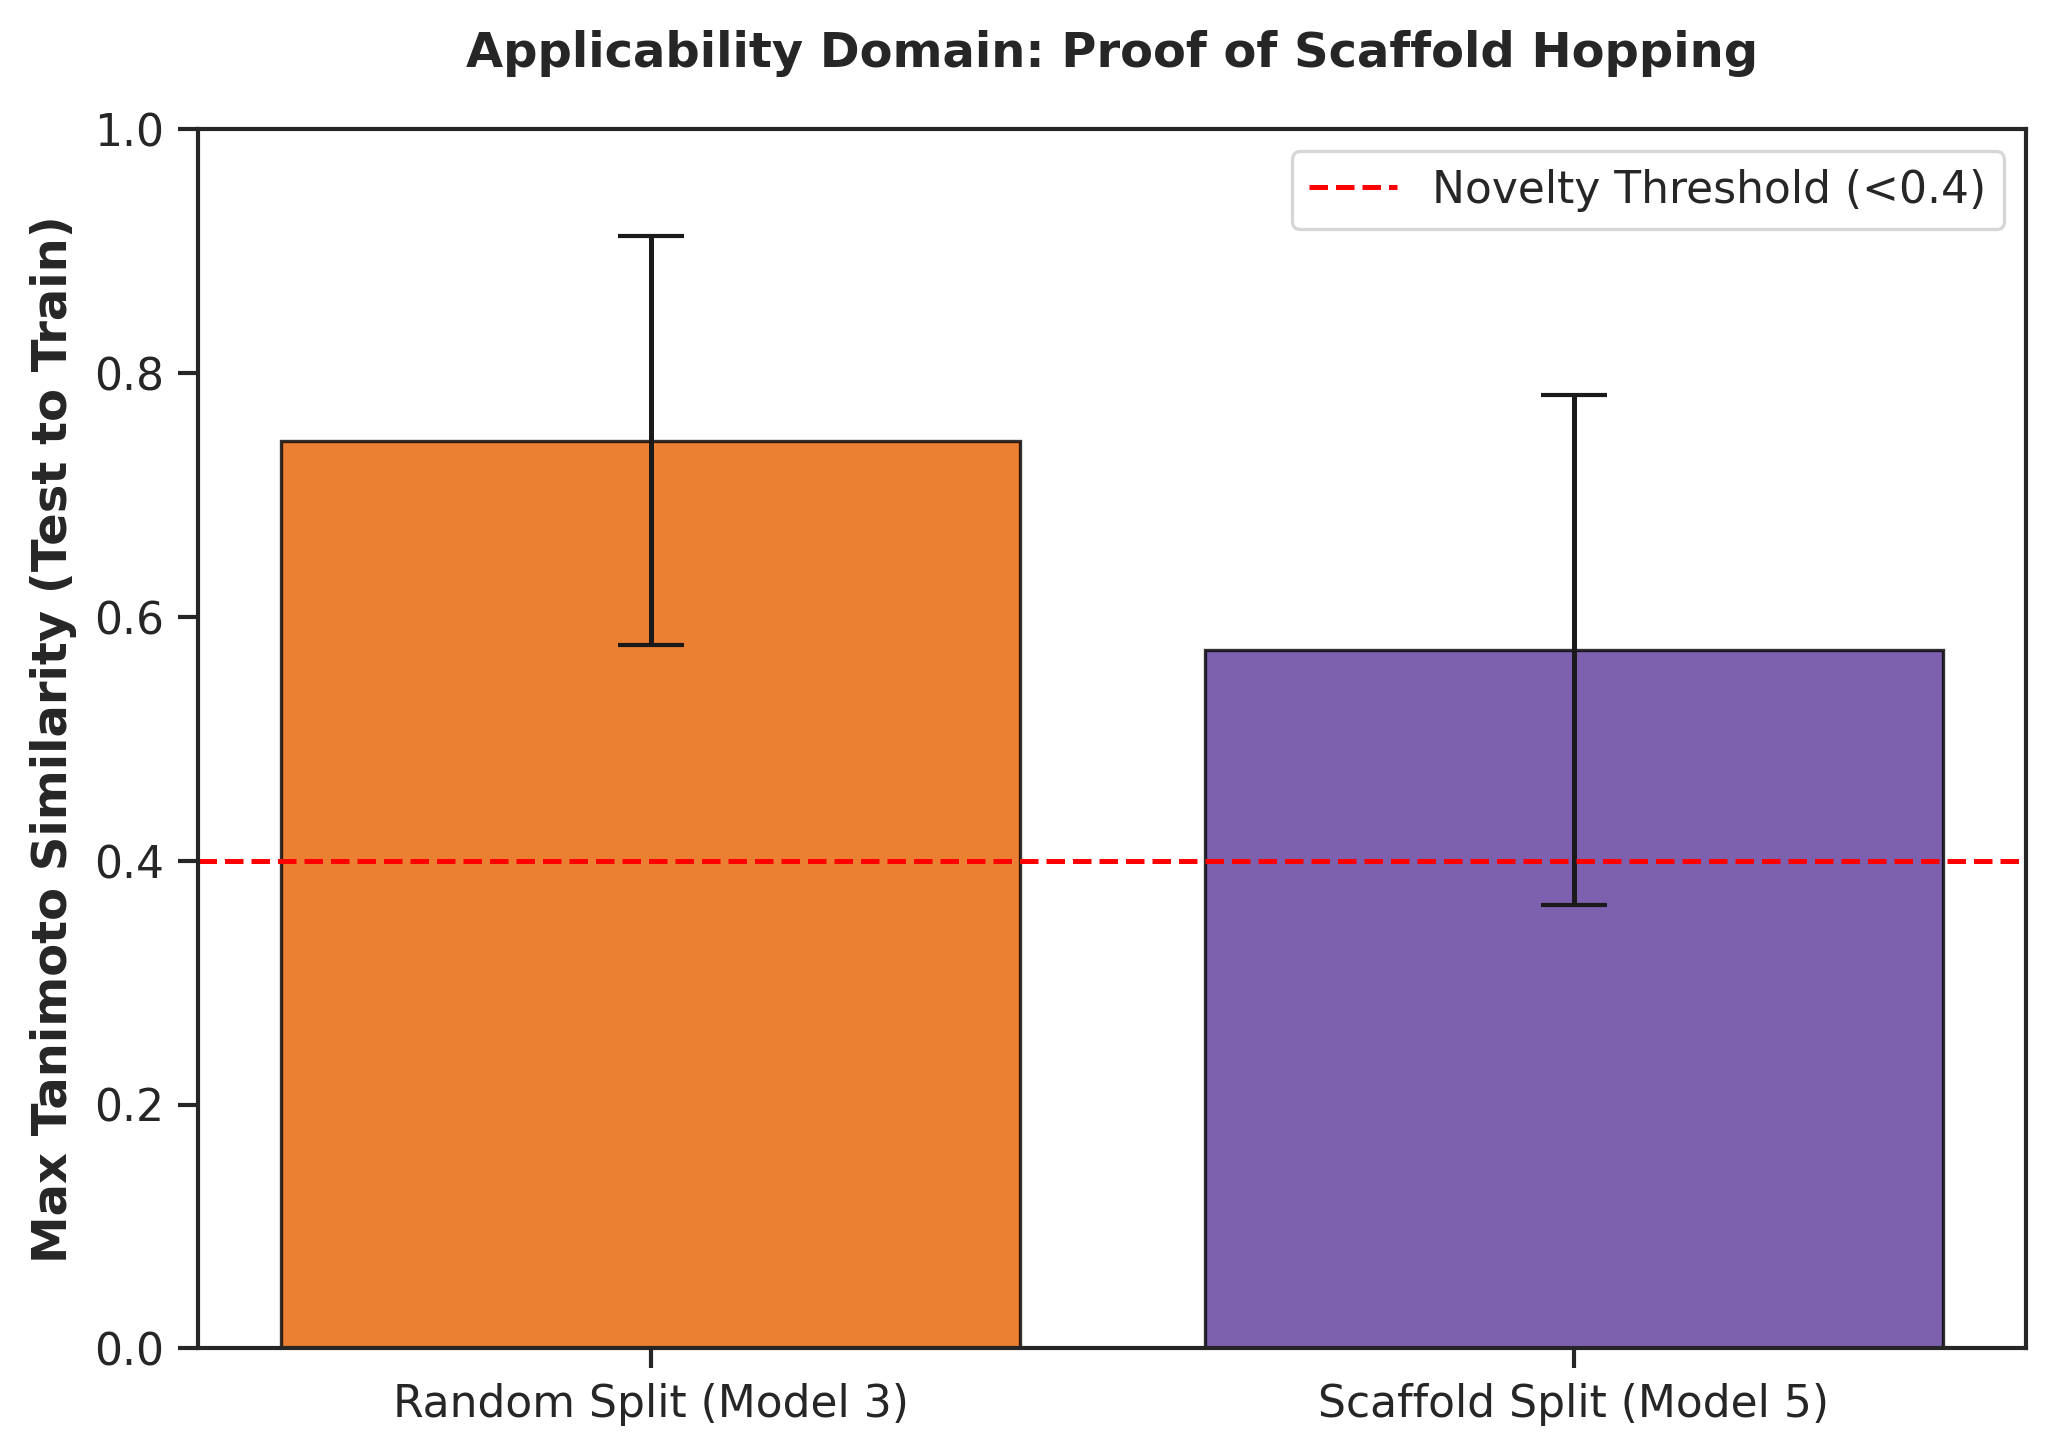

In [3]:
# [Cell 3] Data Leakage Bar Chart (Applicability Domain)
splits = ['Random Split (Model 3)', 'Scaffold Split (Model 5)']
means = [0.7446, 0.5729]
stds = [0.1677, 0.2094]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(splits, means, yerr=stds, capsize=8, color=['#E66100', '#5D3A9B'], alpha=0.8, edgecolor='black')

ax.set_ylabel('Max Tanimoto Similarity (Test to Train)', fontweight='bold')
ax.set_title('Applicability Domain: Proof of Scaffold Hopping', fontweight='bold', pad=15)
ax.set_ylim(0, 1.0)

# Add a horizontal line representing the "Novelty Threshold" (0.4)
ax.axhline(y=0.4, color='red', linestyle='--', label='Novelty Threshold (<0.4)')
ax.legend()

plt.tight_layout()
plt.savefig('figure1_applicability_domain.png')
plt.show()

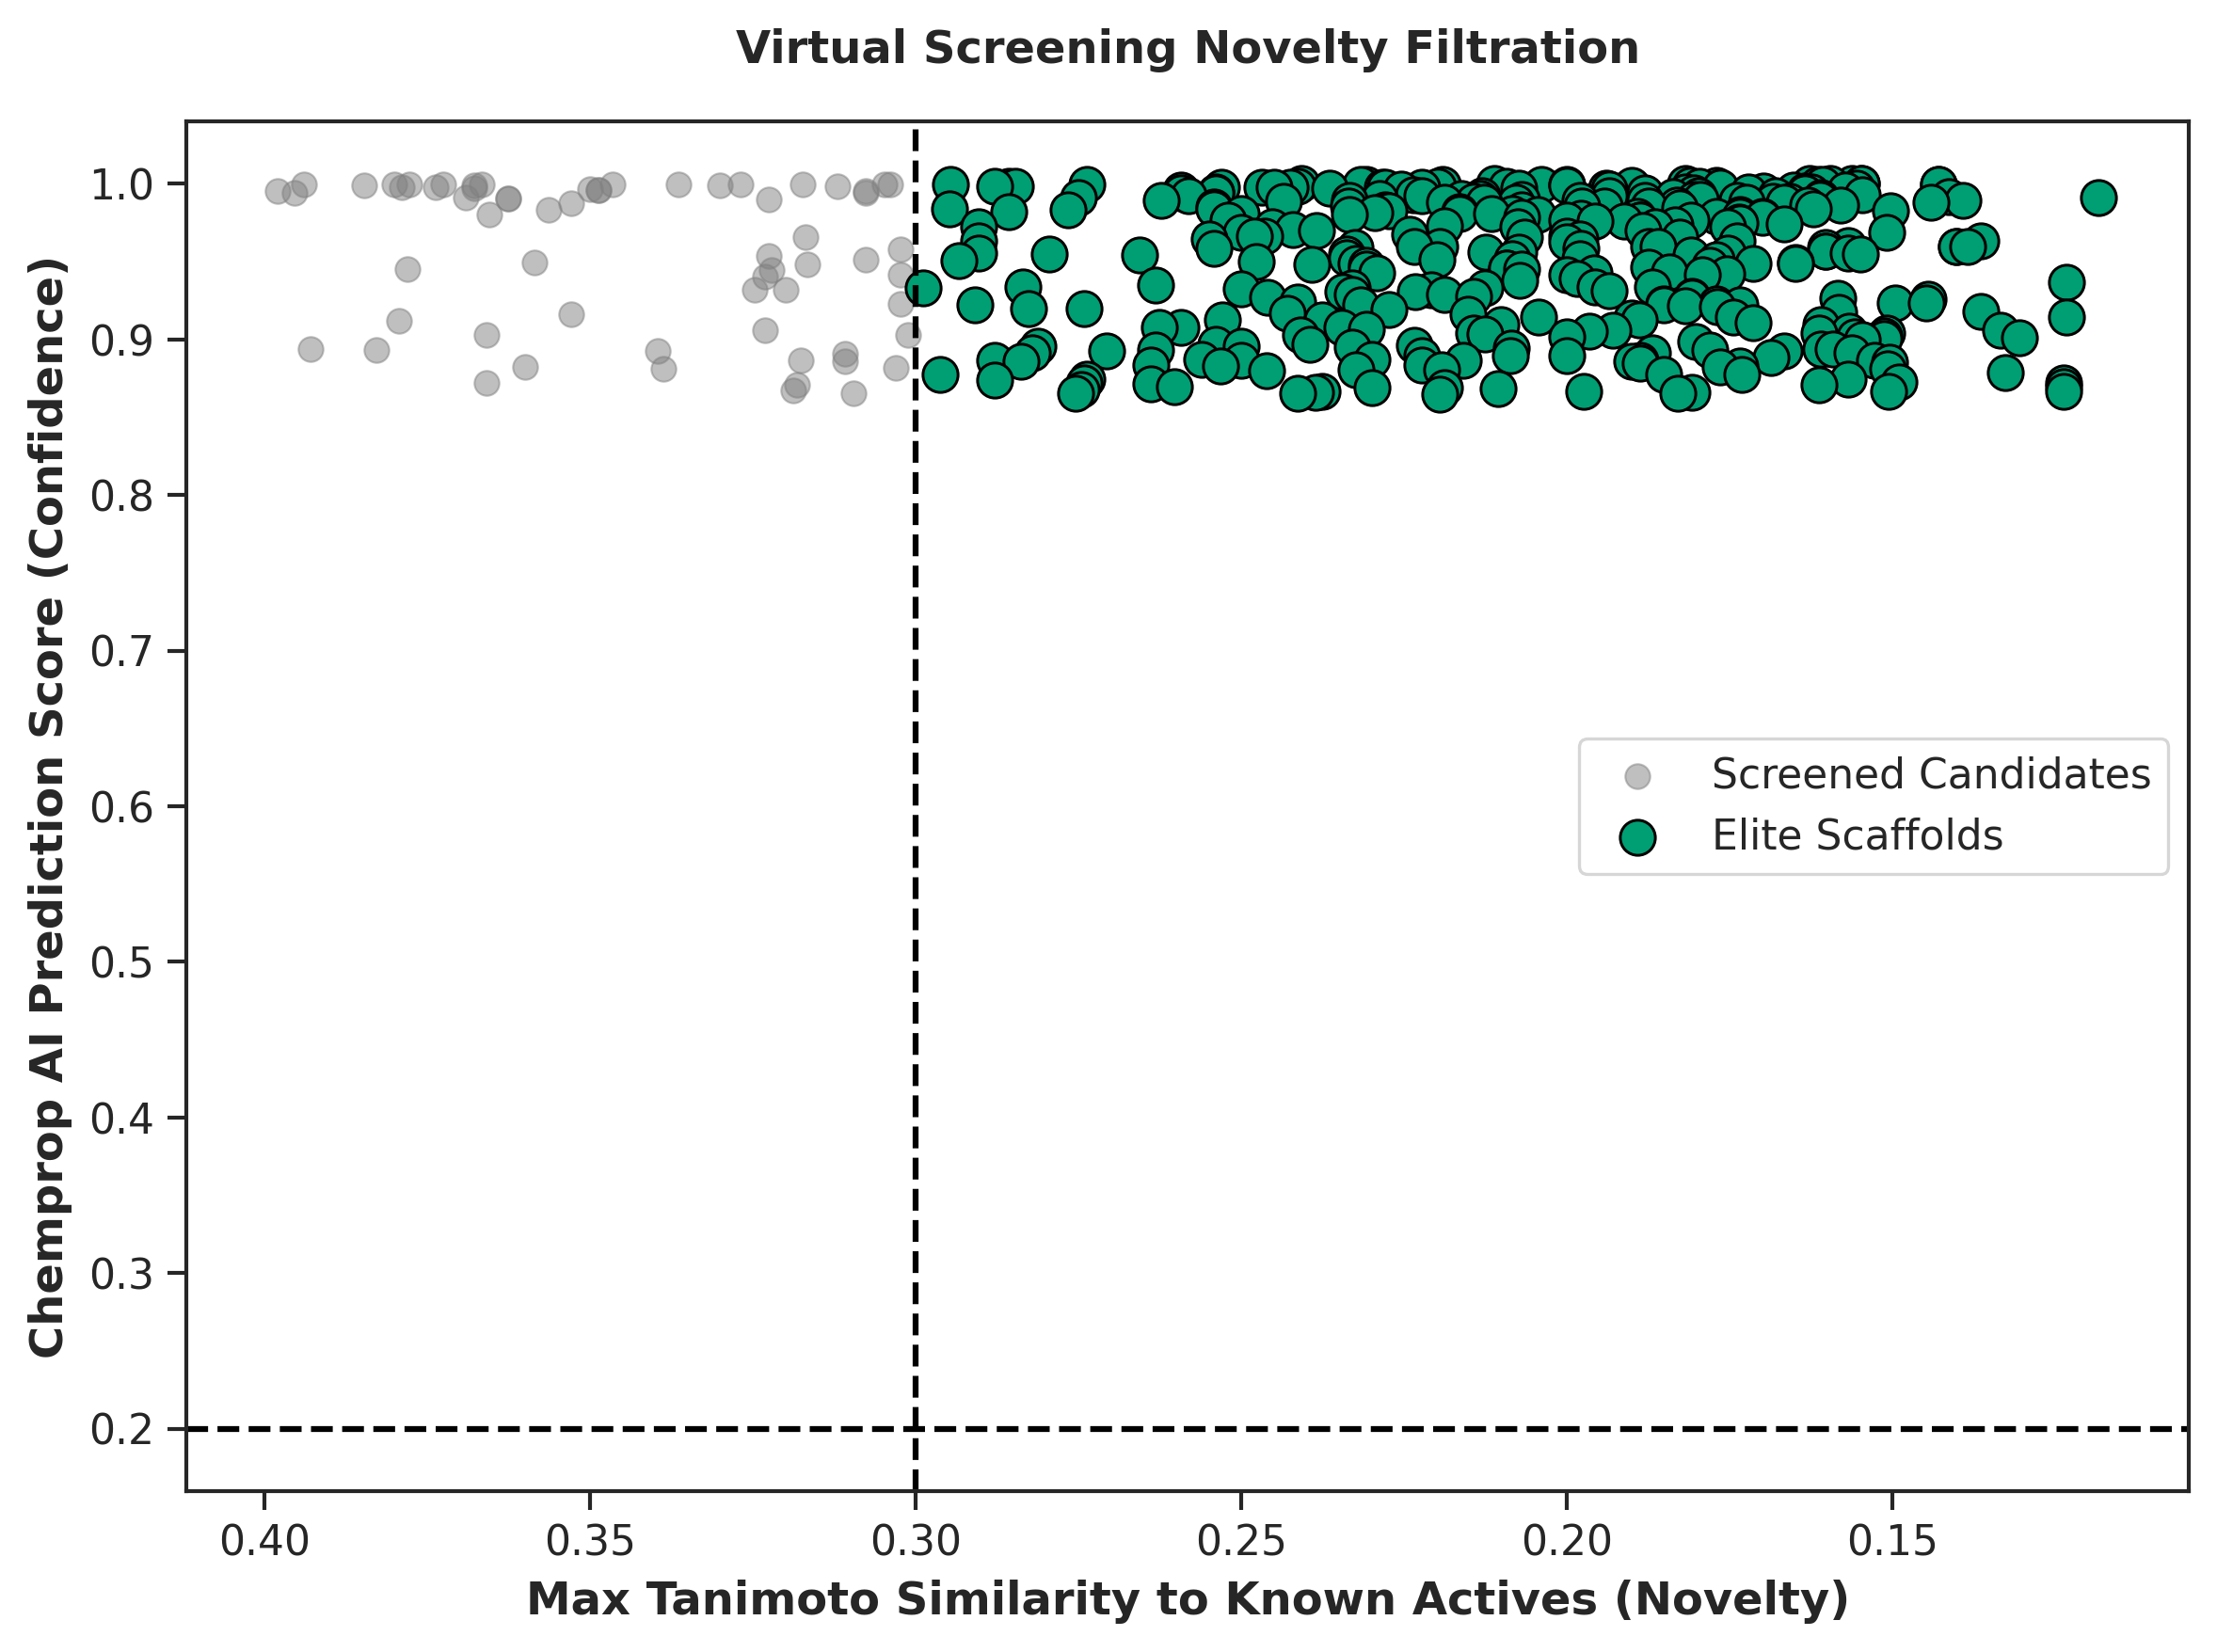

In [6]:
# [Cell 4] AI Score vs. Structural Novelty Scatter Plot
try:
    # Load the novel scaffold hits file (before strict thresholding was applied to see the spread)
    df_hits = pd.read_csv('../results/v6_novel_scaffold_hits.csv')
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot all points in grey
    sns.scatterplot(data=df_hits, x='nearest_neighbor_similarity', y='activity', 
                    color='grey', alpha=0.5, s=40, edgecolor=None, ax=ax, label='Screened Candidates')
    
    # Highlight the elite points (Activity > 0.2 AND Similarity < 0.3)
    elite_mask = (df_hits['activity'] > 0.2) & (df_hits['nearest_neighbor_similarity'] < 0.3)
    sns.scatterplot(data=df_hits[elite_mask], x='nearest_neighbor_similarity', y='activity', 
                    color='#009E73', s=80, edgecolor='black', ax=ax, label='Elite Scaffolds')
    
    # Draw threshold lines
    ax.axvline(x=0.3, color='black', linestyle='--', linewidth=1.5)
    ax.axhline(y=0.2, color='black', linestyle='--', linewidth=1.5)
    
    # Labels
    ax.set_xlabel('Max Tanimoto Similarity to Known Actives (Novelty)', fontweight='bold')
    ax.set_ylabel('Chemprop AI Prediction Score (Confidence)', fontweight='bold')
    ax.set_title('Virtual Screening Novelty Filtration', fontweight='bold', pad=15)
    
    # Invert X axis so "more novel" (lower similarity) is on the right side
    ax.invert_xaxis()
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('figure2_novelty_filter.png')
    plt.show()

except FileNotFoundError:
    print("Please ensure 'results/v6_novel_scaffold_hits.csv' is generated and in the correct folder.")

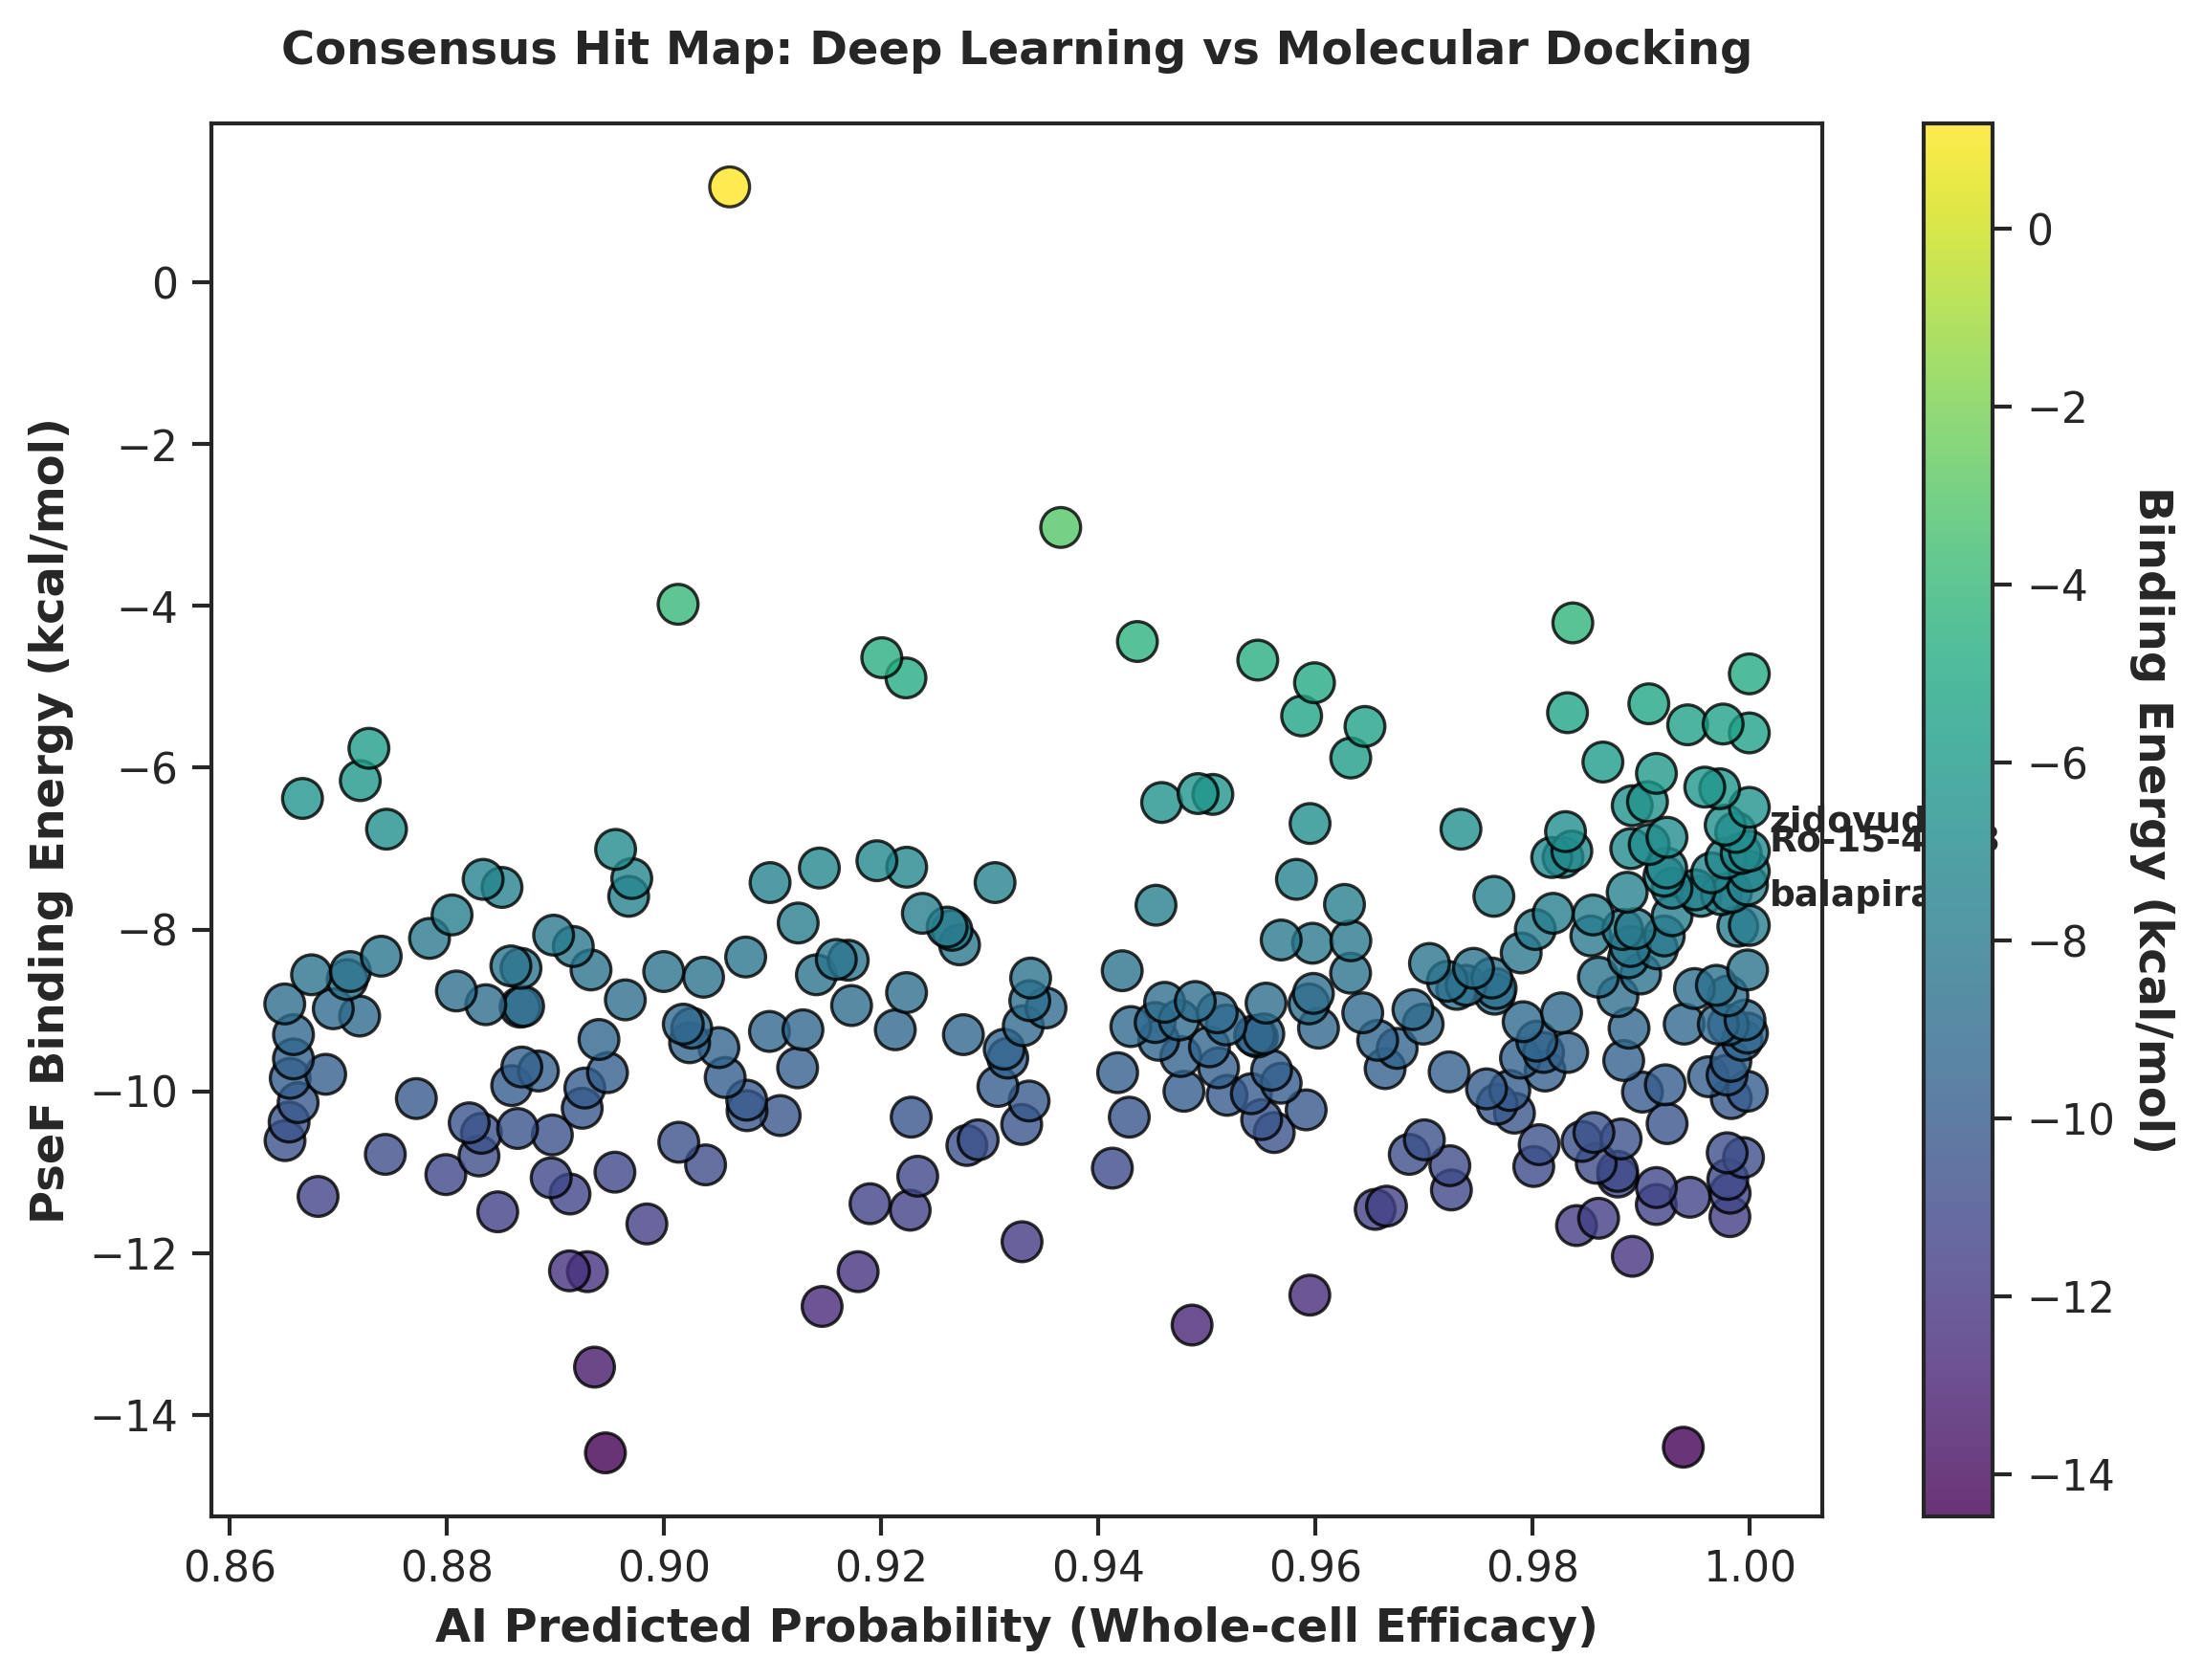

In [7]:
# [Cell 5] AI Consensus vs. Molecular Docking Energy
try:
    df_consensus = pd.read_csv('../results/v6_final_consensus_hits.csv')
    
    # Identify the docking energy column dynamically
    energy_col = next((col for col in df_consensus.columns if 'Energy' in col or 'kcal/mol' in col), None)
    
    if energy_col:
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # We use a color gradient based on the docking energy
        scatter = ax.scatter(df_consensus['activity'], df_consensus[energy_col], 
                             c=df_consensus[energy_col], cmap='viridis', 
                             s=100, edgecolor='black', alpha=0.8)
        
        # Add a colorbar
        cbar = plt.colorbar(scatter)
        cbar.set_label('Binding Energy (kcal/mol)', rotation=270, labelpad=15, fontweight='bold')
        
        # Labels and Title
        ax.set_xlabel('AI Predicted Probability (Whole-cell Efficacy)', fontweight='bold')
        ax.set_ylabel('PseF Binding Energy (kcal/mol)', fontweight='bold')
        ax.set_title('Consensus Hit Map: Deep Learning vs Molecular Docking', fontweight='bold', pad=15)
        
        # Annotate the top 3 best compounds (highest AI, lowest Energy)
        # Sort by AI high, Energy low
        df_top3 = df_consensus.sort_values(by=['activity', energy_col], ascending=[False, True]).head(3)
        for _, row in df_top3.iterrows():
            ax.annotate(row['pert_iname'], 
                        (row['activity'], row[energy_col]),
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.savefig('figure3_consensus_docking.png')
        plt.show()
    else:
        print("Could not find Binding Energy column.")

except FileNotFoundError:
    print("Please ensure 'results/v6_final_consensus_hits.csv' is generated.")

In [8]:
# [Cell 6] Final Consensus Hits Table
try:
    df_final = pd.read_csv('results/v6_final_gastric_approved_hits.csv')
    
    # Select columns to display
    energy_col = next((col for col in df_final.columns if 'Energy' in col or 'kcal/mol' in col), 'Binding Energy (kcal/mol)')
    cols_to_show = ['pert_iname', 'activity', 'nearest_neighbor_similarity', energy_col, 'TPSA', 'Gastric_Permeability']
    
    # Format the numeric columns for a cleaner look
    df_display = df_final[cols_to_show].head(10).copy()
    df_display['activity'] = df_display['activity'].round(3)
    df_display['nearest_neighbor_similarity'] = df_display['nearest_neighbor_similarity'].round(3)
    if energy_col in df_display.columns:
        df_display[energy_col] = df_display[energy_col].round(2)
    
    # Rename for the table
    df_display.columns = ['Compound Name', 'AI Probability', 'Tanimoto Similarity', 'Docking (kcal/mol)', 'TPSA', 'Permeability']
    
    display(df_display.style.set_caption("Table 2: Top Consensus Candidates (Gastric & AI Approved)")
            .hide(axis="index")
            .background_gradient(subset=['AI Probability'], cmap='Greens')
            .background_gradient(subset=['Docking (kcal/mol)'], cmap='Blues_r'))

except FileNotFoundError:
    print("Please ensure 'results/v6_final_gastric_approved_hits.csv' is generated.")

Please ensure 'results/v6_final_gastric_approved_hits.csv' is generated.


In [9]:
# [Cell 1] Advanced Publication Styling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# High-impact journal styling
plt.style.use('default')
sns.set_theme(style="ticks", context="paper", font_scale=1.3)
plt.rcParams['font.family'] = 'Arial' # Standard for Nature/ACS journals
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.format'] = 'pdf' # Vector graphics for crisp publication

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

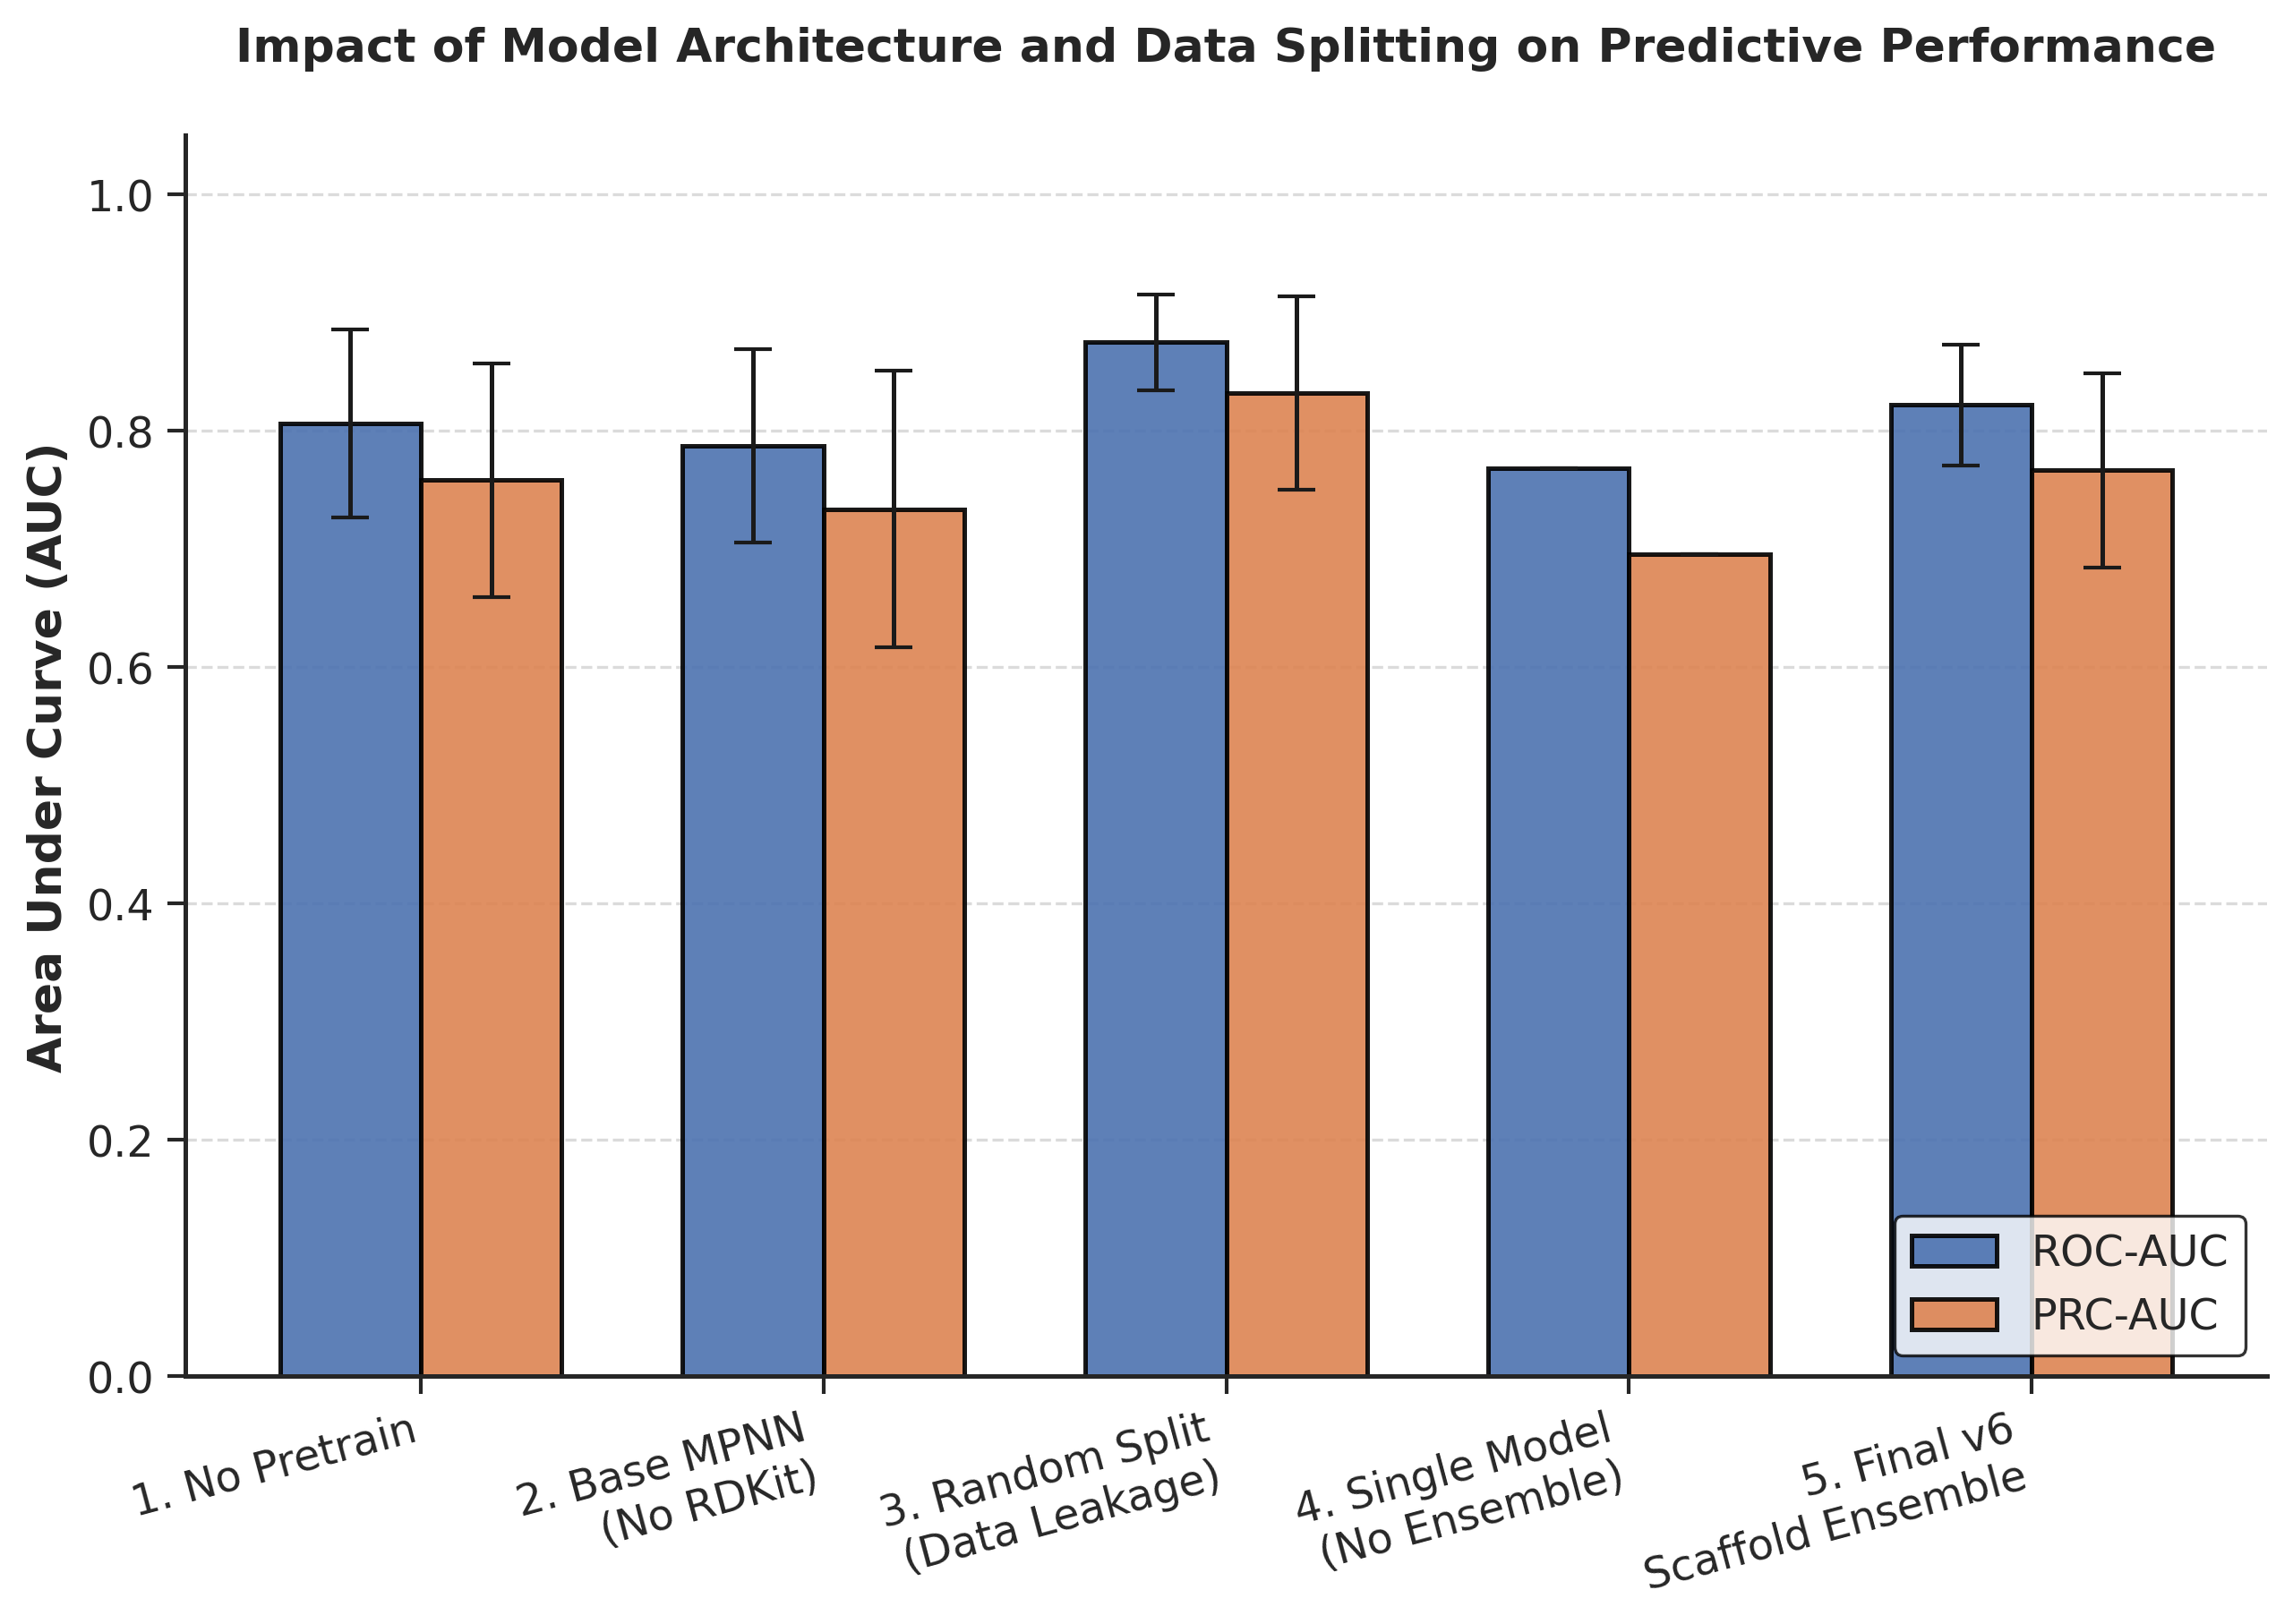

In [10]:
# [Cell 2] Professional Ablation & Validation Chart
labels = ['1. No Pretrain', '2. Base MPNN\n(No RDKit)', '3. Random Split\n(Data Leakage)', 
          '4. Single Model\n(No Ensemble)', '5. Final v6\nScaffold Ensemble']

roc_auc = [0.8065, 0.7876, 0.8750, 0.7682, 0.8221]
roc_err = [0.0794, 0.0817, 0.0405, 0.0000, 0.0509]

prc_auc = [0.7584, 0.7340, 0.8321, 0.6958, 0.7668]
prc_err = [0.0988, 0.1168, 0.0818, 0.0000, 0.0822]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Use muted, professional colors
rects1 = ax.bar(x - width/2, roc_auc, width, yerr=roc_err, label='ROC-AUC', 
                color='#4C72B0', edgecolor='black', linewidth=1.2, capsize=5, alpha=0.9)
rects2 = ax.bar(x + width/2, prc_auc, width, yerr=prc_err, label='PRC-AUC', 
                color='#DD8452', edgecolor='black', linewidth=1.2, capsize=5, alpha=0.9)

ax.set_ylabel('Area Under Curve (AUC)', fontweight='bold')
ax.set_title('Impact of Model Architecture and Data Splitting on Predictive Performance', pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)

# Clean up axes
sns.despine()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind bars

ax.legend(loc='lower right', frameon=True, edgecolor='black')

plt.savefig('Fig1_Model_Ablation.pdf')
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

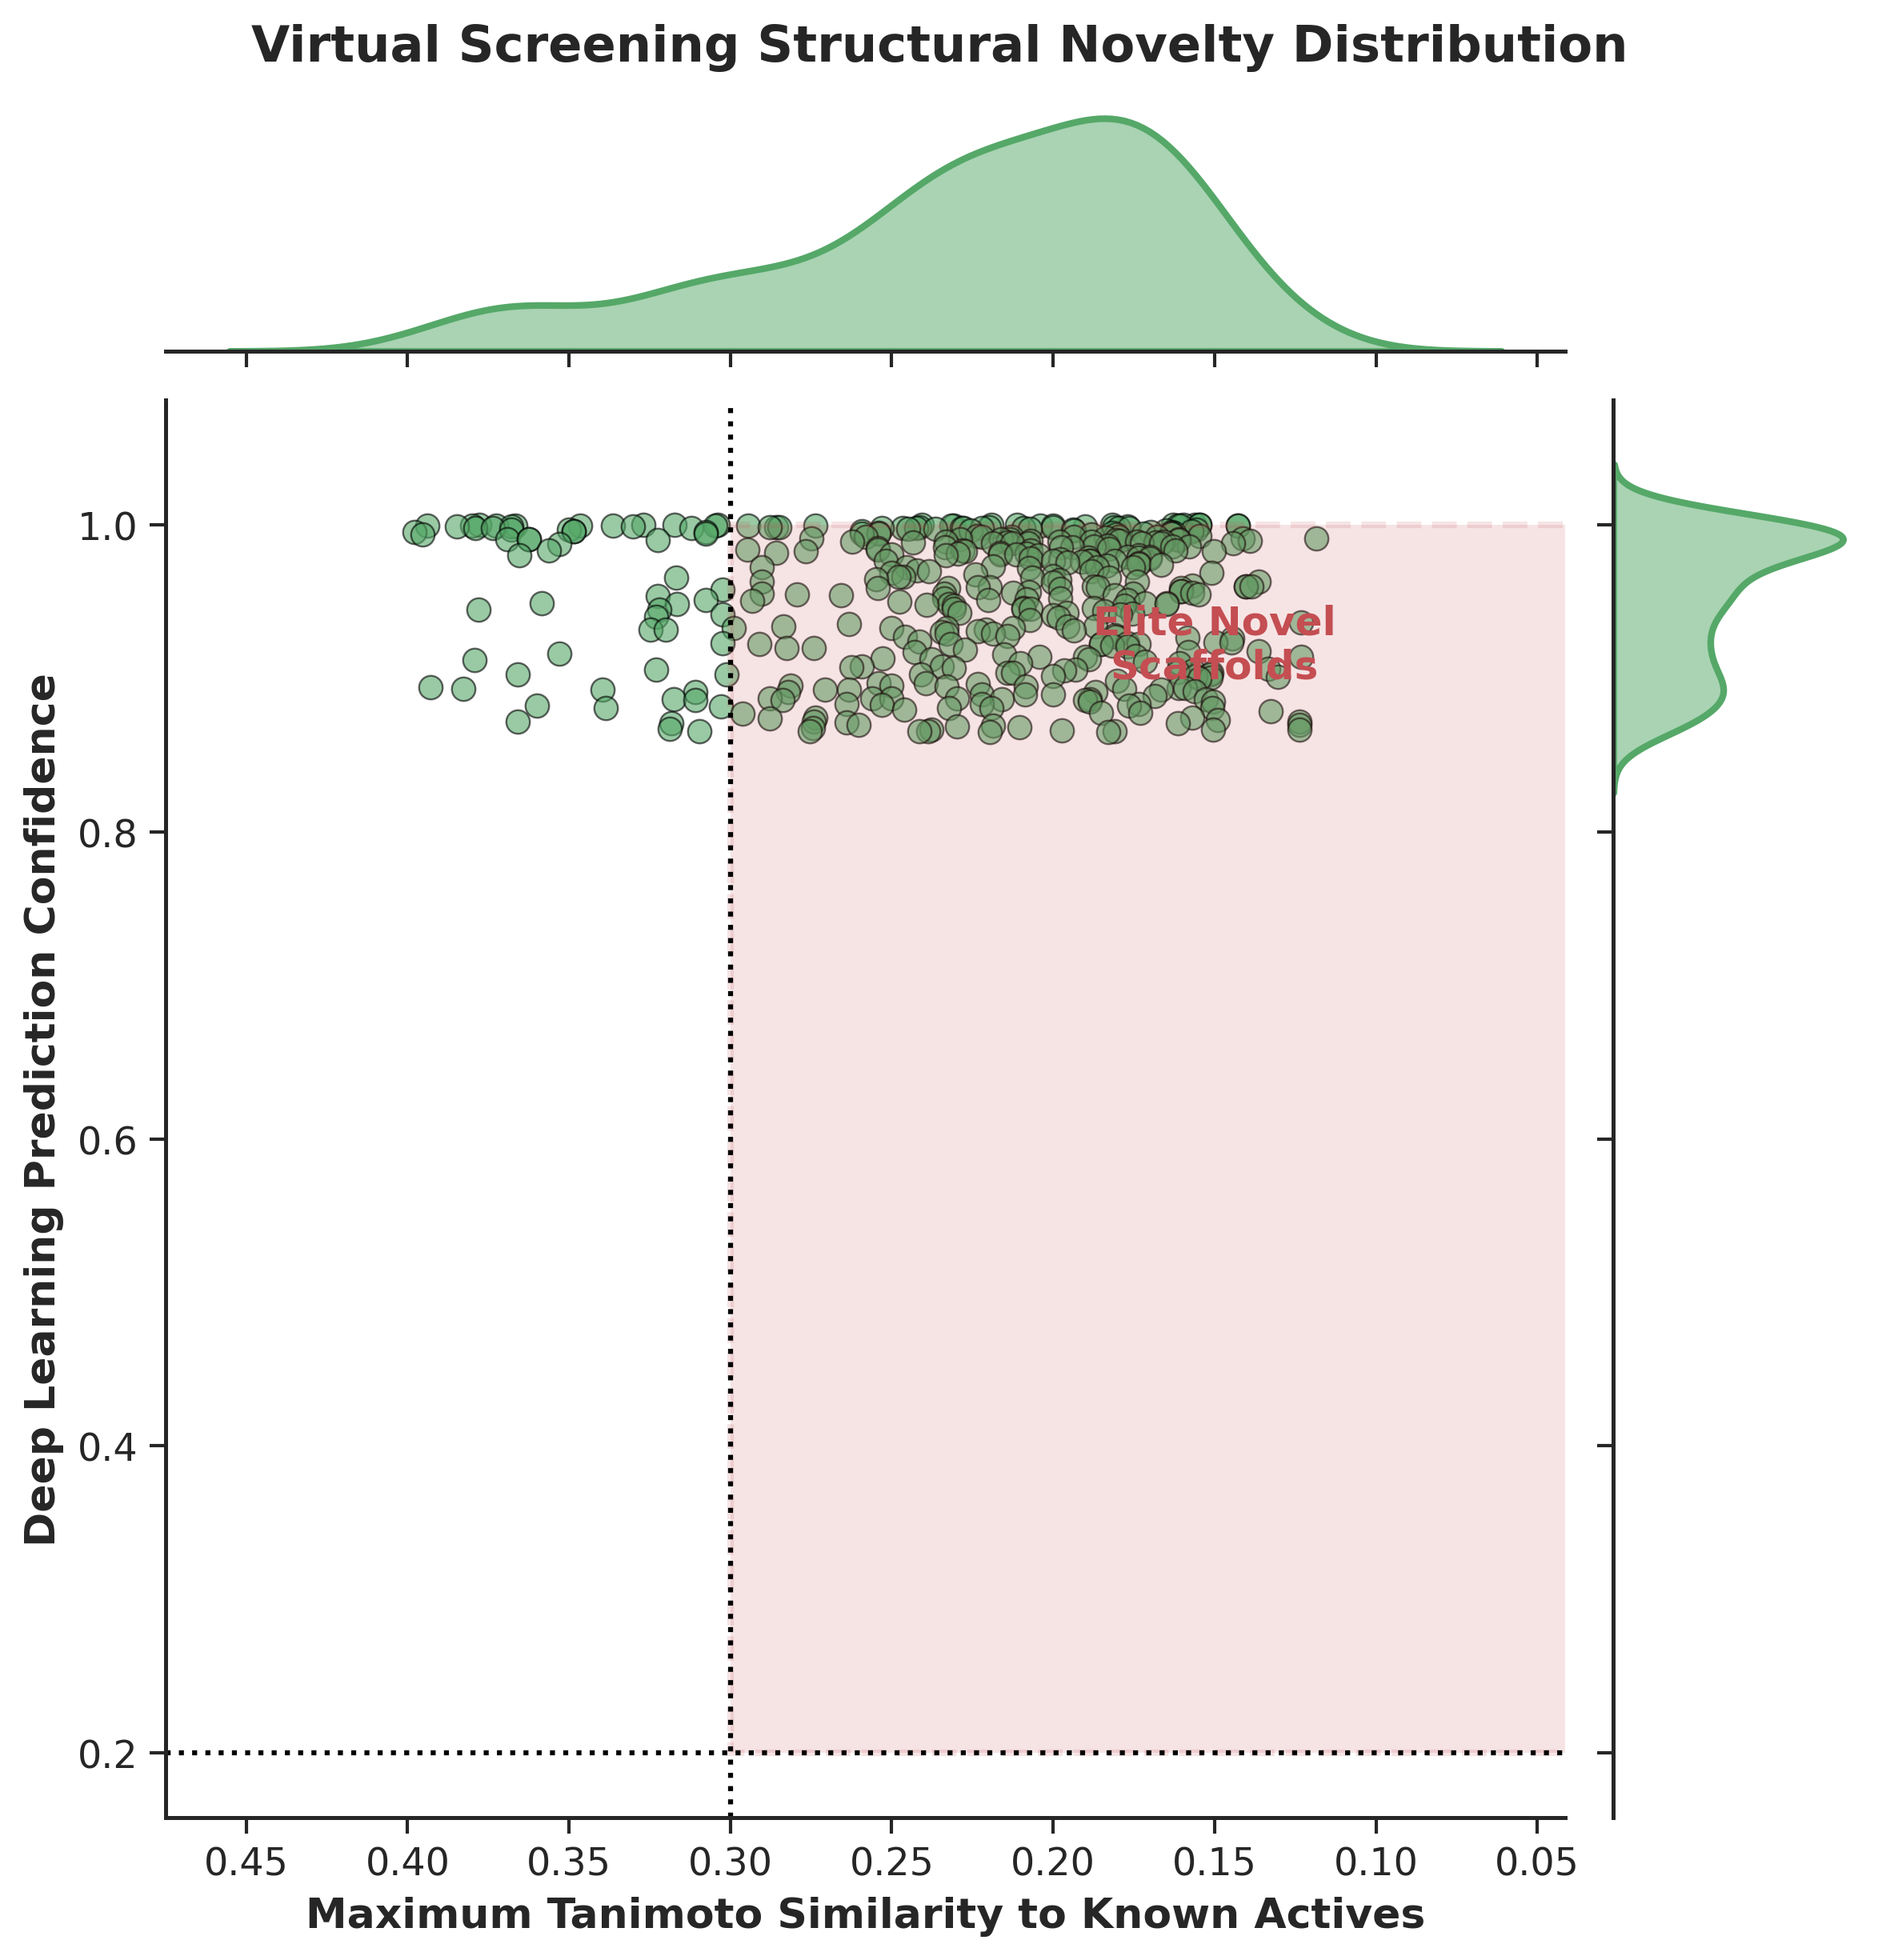

In [12]:
# [Cell 3] Professional JointPlot for Novelty/Scaffold Hopping
try:
    df_hits = pd.read_csv('../results/v6_novel_scaffold_hits.csv')
    
    # Create the JointGrid
    g = sns.JointGrid(data=df_hits, x='nearest_neighbor_similarity', y='activity', height=8, ratio=5)

    # Add the scatter plot with alpha for density visualization
    g.plot_joint(sns.scatterplot, color='#55A868', alpha=0.6, edgecolor='black', s=50)

    # Add Density (KDE) plots on the margins
    g.plot_marginals(sns.kdeplot, color='#55A868', fill=True, alpha=0.5, linewidth=2)

    # Highlight the "Elite Target Region" (Similarity < 0.3, Activity > 0.2)
    ax = g.ax_joint
    rect = patches.Rectangle((0, 0.2), 0.3, 0.8, linewidth=2, edgecolor='#C44E52', facecolor='#C44E52', alpha=0.15, linestyle='--')
    ax.add_patch(rect)
    ax.text(0.15, 0.9, 'Elite Novel\nScaffolds', color='#C44E52', fontsize=12, fontweight='bold', ha='center')

    # Formatting
    ax.set_xlabel('Maximum Tanimoto Similarity to Known Actives', fontweight='bold')
    ax.set_ylabel('Deep Learning Prediction Confidence', fontweight='bold')
    
    # Invert X axis so that "More Novel" (lower similarity) is on the right, which feels more natural for a "better" score
    ax.invert_xaxis()
    
    # Add threshold lines
    ax.axvline(x=0.3, color='black', linestyle=':', linewidth=1.5)
    ax.axhline(y=0.2, color='black', linestyle=':', linewidth=1.5)

    plt.suptitle('Virtual Screening Structural Novelty Distribution', fontweight='bold', y=1.02)
    plt.savefig('Fig2_Scaffold_Hopping_JointPlot.pdf')
    plt.show()

except FileNotFoundError:
    print("Ensure 'results/v6_novel_scaffold_hits.csv' is available.")

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

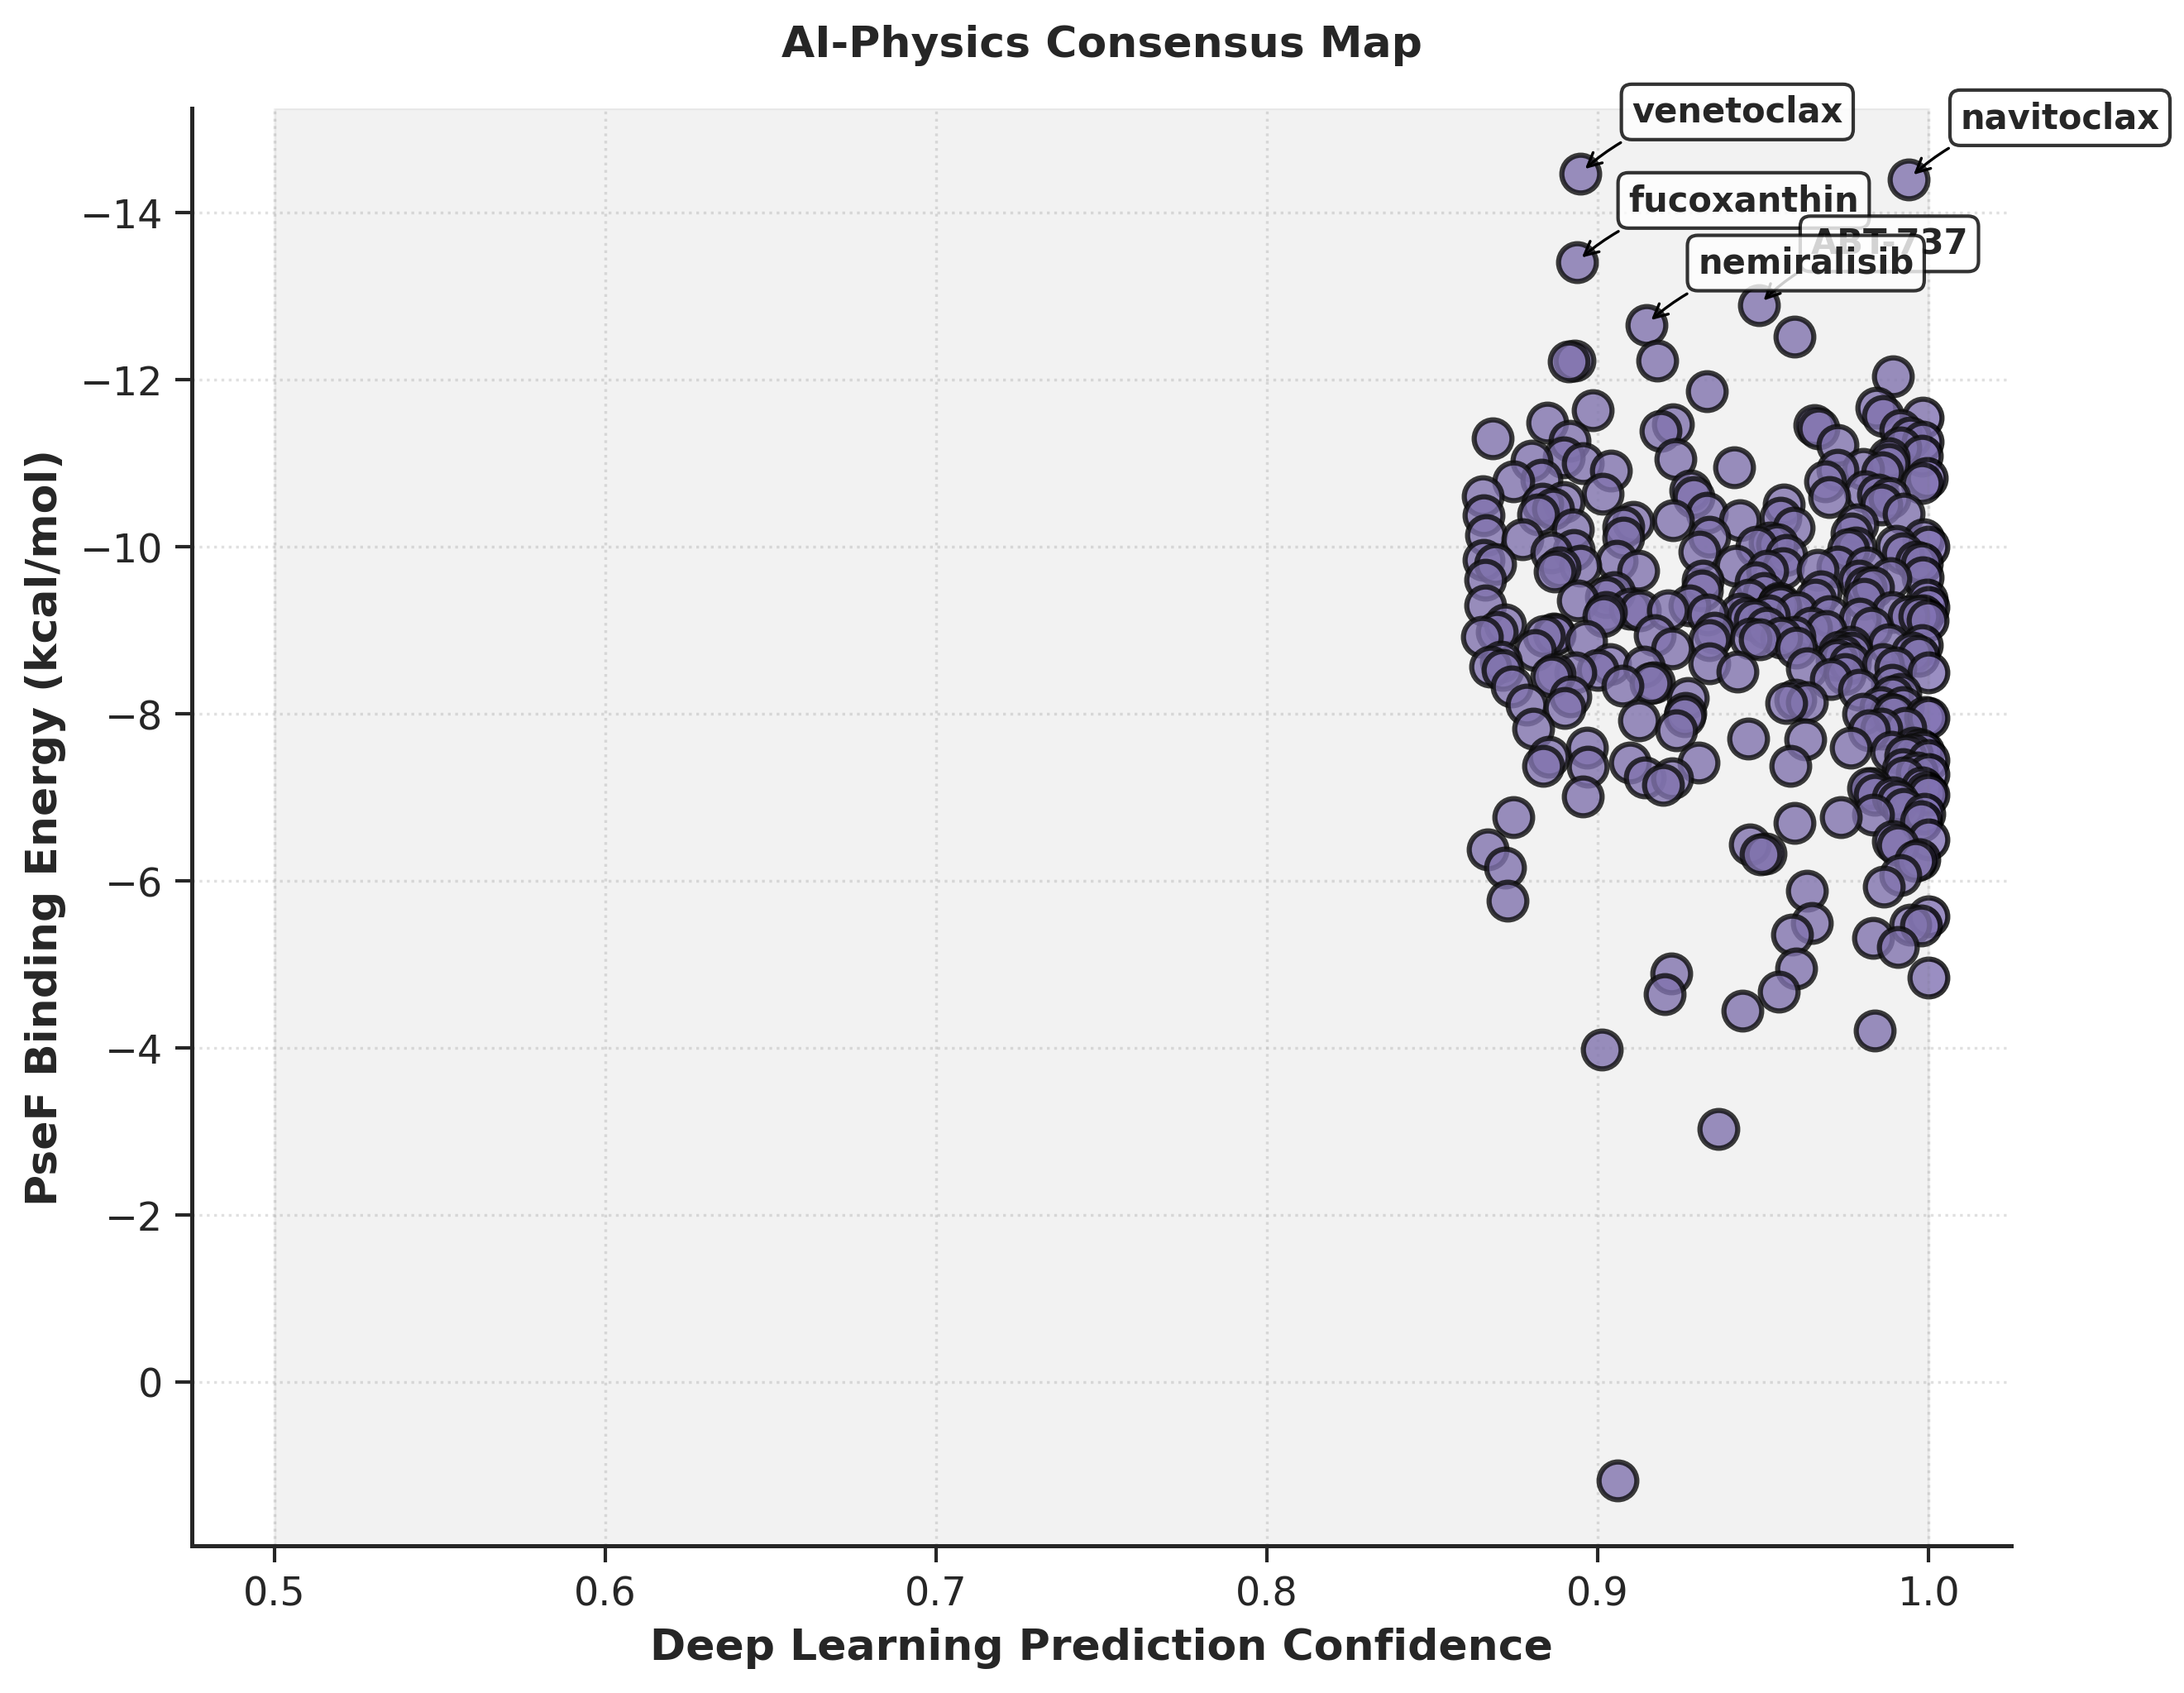

In [14]:
# [Cell 4] Consensus Bubble Plot (AI vs Molecular Docking)
try:
    df_consensus = pd.read_csv('../results/v6_final_consensus_hits.csv')
    
    # Auto-detect docking column
    energy_col = next((col for col in df_consensus.columns if 'Energy' in col or 'kcal/mol' in col), None)
    
    if energy_col:
        fig, ax = plt.subplots(figsize=(9, 7))
        
        # We invert the Y-axis so that "Lower Energy" (better binding) goes UP towards the top right with high AI
        # This makes the "Top Right" the best quadrant, which is intuitive for readers.
        
        scatter = ax.scatter(df_consensus['activity'], df_consensus[energy_col], 
                             c='#8172B3', s=120, edgecolor='black', linewidth=1.5, alpha=0.8)
        
        # Format axes
        ax.set_xlabel('Deep Learning Prediction Confidence', fontweight='bold')
        ax.set_ylabel('PseF Binding Energy (kcal/mol)', fontweight='bold')
        ax.set_title('AI-Physics Consensus Map', fontweight='bold', pad=15)
        
        # Invert Y axis: Lower kcal/mol = Stronger binding = Higher on graph
        ax.invert_yaxis()
        
        # Shaded optimal quadrant (High AI, Strong Binding)
        # Assuming binding energy < -7.0 is highly favorable
        ax.axvspan(0.5, 1.0, color='grey', alpha=0.1)
        
        # Annotate the absolute top 5 candidates with arrows
        df_top = df_consensus.sort_values(by=[energy_col, 'activity'], ascending=[True, False]).head(5)
        
        for i, row in df_top.iterrows():
            ax.annotate(row['pert_iname'], 
                        (row['activity'], row[energy_col]),
                        xytext=(15, 15), textcoords='offset points',
                        fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.8),
                        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black'))

        sns.despine()
        ax.grid(True, linestyle=':', alpha=0.6)
        
        plt.tight_layout()
        plt.savefig('Fig3_Consensus_Docking.pdf')
        plt.show()

except FileNotFoundError:
    print("Ensure 'results/v6_final_consensus_hits.csv' is available.")

In [16]:
# [Validation Cell 1] ROC and PRC Curves
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Professional Styling
plt.style.use('default')
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 300

# --- UPDATE THIS PATH TO YOUR TEST SET PREDICTIONS ---
test_results_file = '../results/v6_test_predictions.csv' 

try:
    df_test = pd.read_csv(test_results_file)
    
    # Assuming 'activity' is the true label and 'pred_activity' is the Chemprop prediction
    # If Chemprop overwrote the column, you might need to adjust these names
    y_true = df_test['activity']       # True binary labels (0 or 1)
    y_scores = df_test['pred_activity'] # Predicted probabilities (0.0 to 1.0)
    
    # Calculate Metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    prc_auc = average_precision_score(y_true, y_scores)
    
    # Create the Subplots (1 Row, 2 Columns)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    
    # Plot 1: ROC Curve
    ax1 = axes[0]
    ax1.plot(fpr, tpr, color='#C44E52', lw=2.5, label=f'v6 Ensemble (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
    ax1.set_xlim([-0.02, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontweight='bold')
    ax1.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold', pad=15)
    ax1.legend(loc="lower right", frameon=True, edgecolor='black')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Plot 2: Precision-Recall Curve
    ax2 = axes[1]
    # Calculate baseline for PRC (fraction of positives)
    baseline = sum(y_true) / len(y_true)
    ax2.plot(recall, precision, color='#4C72B0', lw=2.5, label=f'v6 Ensemble (AUC = {prc_auc:.3f})')
    ax2.axhline(y=baseline, color='grey', lw=1.5, linestyle='--', label=f'Baseline ({baseline:.3f})')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall', fontweight='bold')
    ax2.set_ylabel('Precision', fontweight='bold')
    ax2.set_title('Precision-Recall Curve (PRC)', fontweight='bold', pad=15)
    ax2.legend(loc="lower left", frameon=True, edgecolor='black')
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('Fig4_Model_Validation_Curves.pdf', bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print(f"File not found: {test_results_file}. Please point this to your Chemprop test evaluation output.")
except KeyError as e:
    print(f"Column not found: {e}. Please ensure your CSV has the correct true/pred column names.")

File not found: ../results/v6_test_predictions.csv. Please point this to your Chemprop test evaluation output.


✅ Loaded Ground Truth: 933 molecules.
✅ Processed 1. Train from Scratch (Aligned 93 molecules)
✅ Processed 2. Base MPNN (No RDKit) (Aligned 93 molecules)
✅ Processed 3. Random Split (Leakage) (Aligned 94 molecules)
✅ Processed 4. Single Checkpoint (Aligned 93 molecules)
✅ Processed 5. Final v6 Scaffold Model (Aligned 93 molecules)

✅ Plot successfully saved as ../results/Fig4_MultiModel_Validation_Curves.pdf


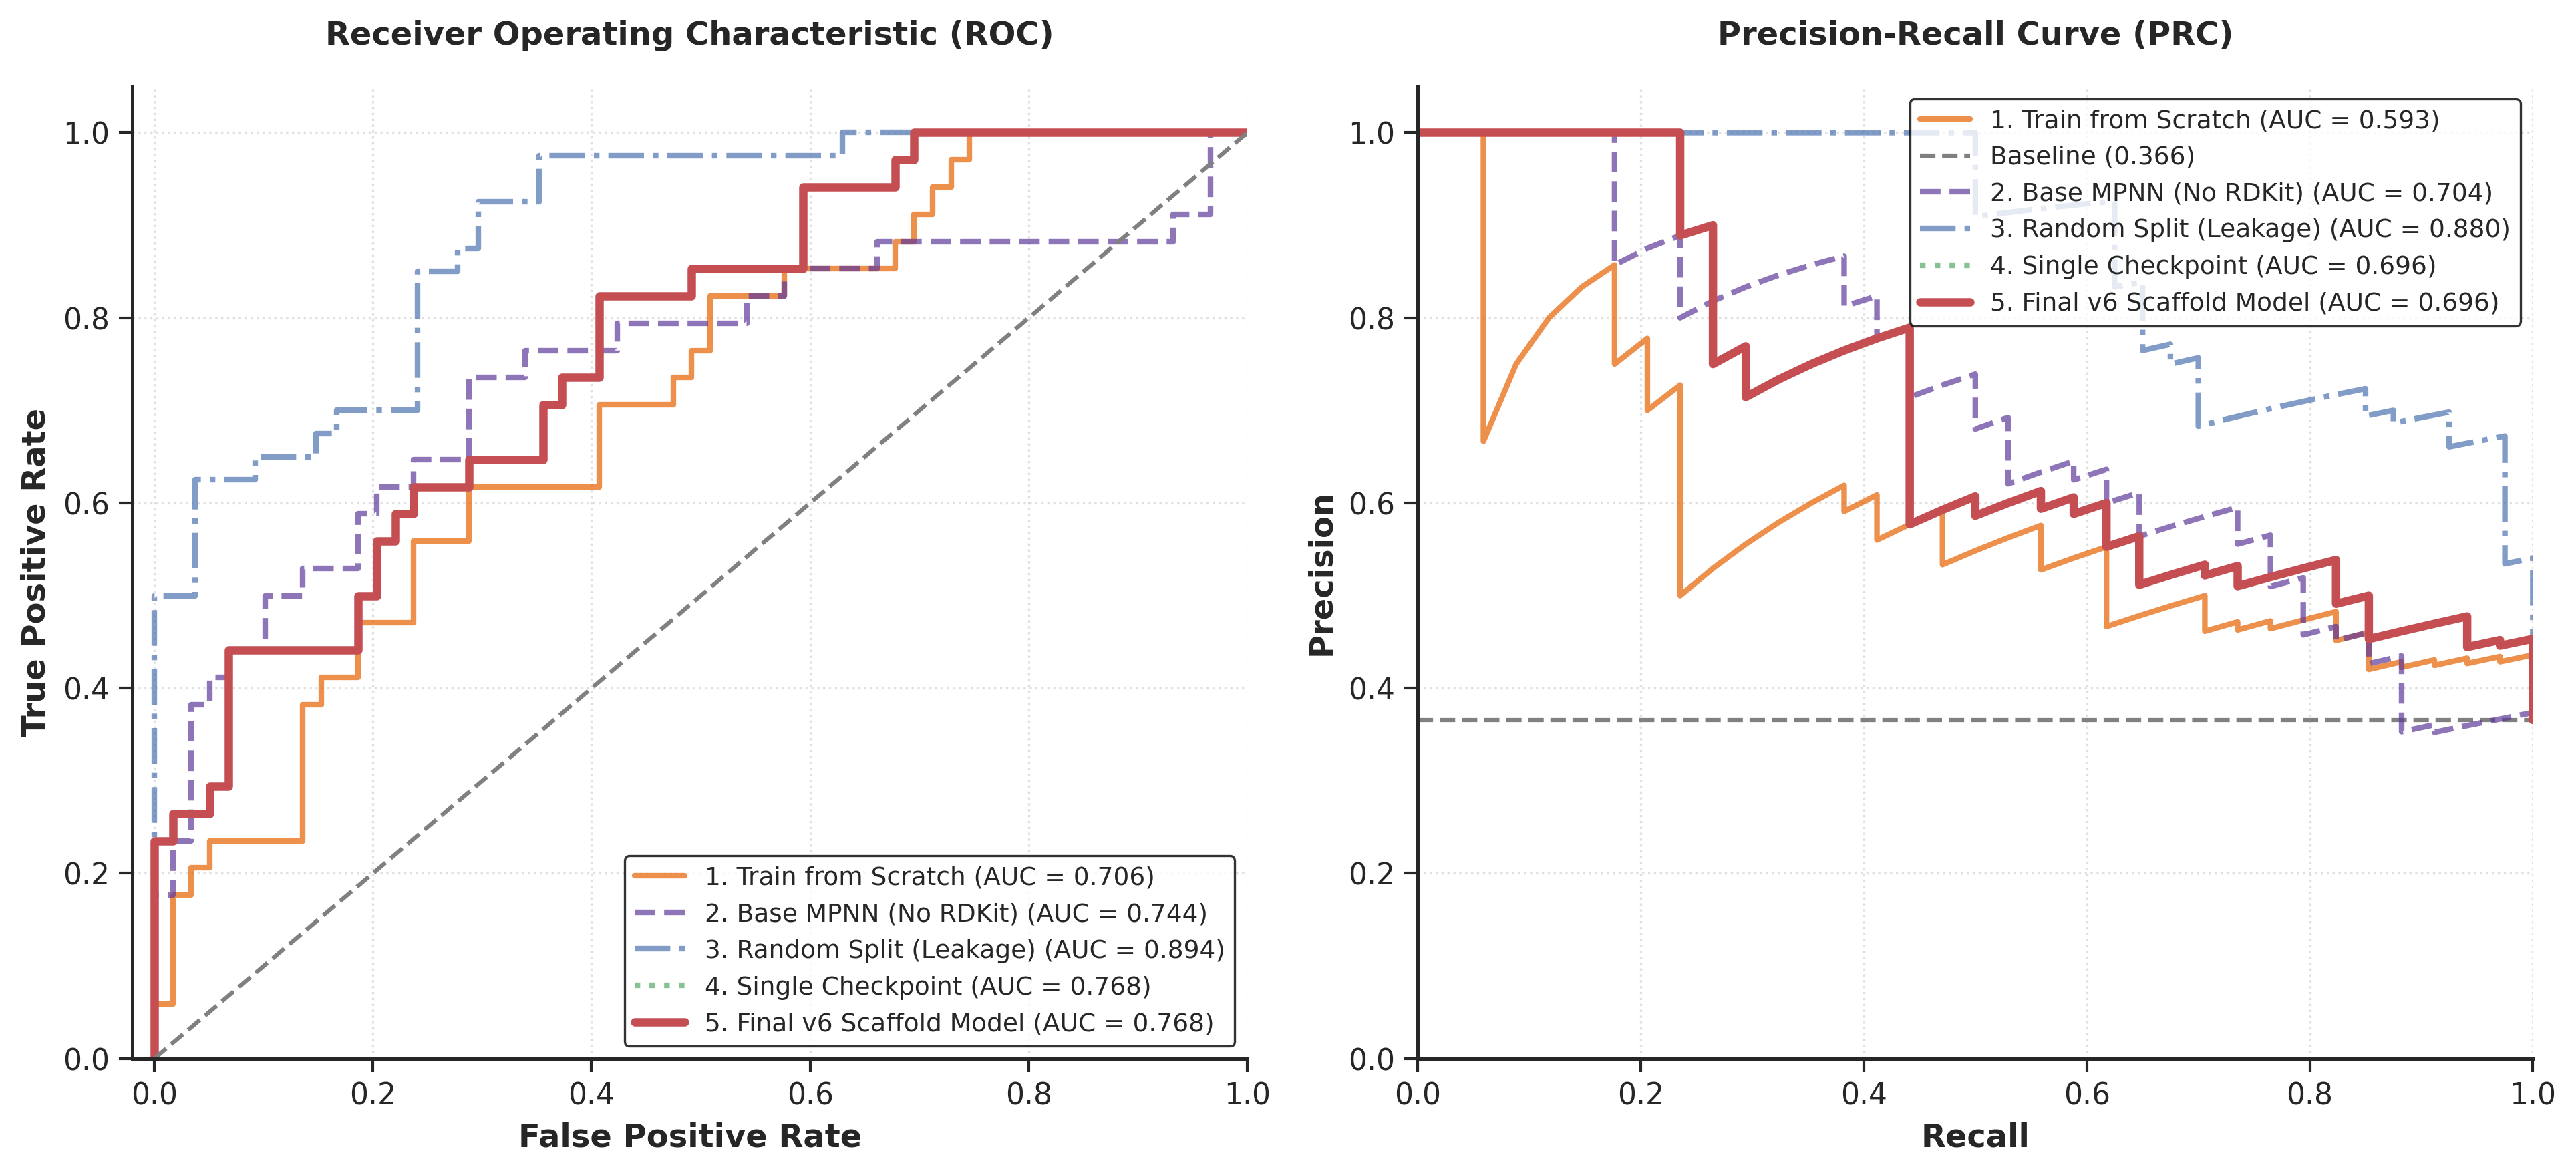

In [23]:
# [Validation Cell] Multi-Model Overlaid ROC and PRC Curves
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Professional Styling (sans-serif to prevent font errors)
plt.style.use('default')
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 300

# 1. Load the Ground Truth Dataset
truth_path = '../data/processed/fine_tune_ext.csv'
try:
    df_truth = pd.read_csv(truth_path)
    # We only need smiles and the true activity
    df_truth = df_truth[['smiles', 'activity']] 
    print(f"✅ Loaded Ground Truth: {len(df_truth)} molecules.")
except FileNotFoundError:
    print(f"❌ Error: Could not find ground truth file at {truth_path}")

# 2. Exact Model Paths (Mapped strictly from your 'tree' output)
model_files = {
    '1. Train from Scratch': '../models/finetune_v6_scratch_scaffold/replicate_0/model_0/test_predictions.csv',
    '2. Base MPNN (No RDKit)': '../models/finetune_v6_base_scaffold/replicate_0/model_0/test_predictions.csv',
    '3. Random Split (Leakage)': '../models/finetune_v6_rdkit_random/replicate_0/model_0/test_predictions.csv',
    '4. Single Checkpoint': '../models/finetune_v6_rdkit_single/model_0/test_predictions.csv',
    '5. Final v6 Scaffold Model': '../models/finetune_v6_rdkit_scaffold/replicate_0/model_0/test_predictions.csv'
}

colors = ['#E66100', '#5D3A9B', '#4C72B0', '#55A868', '#C44E52']
line_styles = ['-', '--', '-.', ':', '-']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
ax1, ax2 = axes[0], axes[1]
baseline_plotted = False

# 3. Process each model
for i, (model_name, file_path) in enumerate(model_files.items()):
    try:
        # Read the predictions
        df_pred = pd.read_csv(file_path)
        
        # Rename the predicted 'activity' column to avoid clashing with the true 'activity' column
        df_pred = df_pred.rename(columns={'activity': 'pred_prob'})
        
        # Merge exactly on the SMILES string
        df_merged = pd.merge(df_truth, df_pred[['smiles', 'pred_prob']], on='smiles', how='inner')
        
        if len(df_merged) == 0:
            print(f"⚠️ {model_name}: No matching SMILES found between prediction and ground truth.")
            continue
            
        y_true = df_merged['activity']
        y_scores = df_merged['pred_prob']
        
        # --- Calculate and Plot ROC ---
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        
        lw = 3.0 if 'Final' in model_name else 2.0
        alpha = 1.0 if 'Final' in model_name else 0.7
        ax1.plot(fpr, tpr, color=colors[i], linestyle=line_styles[i], lw=lw, alpha=alpha, 
                 label=f'{model_name} (AUC = {roc_auc:.3f})')
        
        # --- Calculate and Plot PRC ---
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        prc_auc = average_precision_score(y_true, y_scores)
        
        ax2.plot(recall, precision, color=colors[i], linestyle=line_styles[i], lw=lw, alpha=alpha,
                 label=f'{model_name} (AUC = {prc_auc:.3f})')
        
        # Add the horizontal baseline for the PRC plot once
        if not baseline_plotted:
            baseline = sum(y_true) / len(y_true)
            ax2.axhline(y=baseline, color='grey', lw=1.5, linestyle='--', label=f'Baseline ({baseline:.3f})')
            baseline_plotted = True
            
        print(f"✅ Processed {model_name} (Aligned {len(df_merged)} molecules)")
            
    except FileNotFoundError:
        print(f"⚠️ Skipping {model_name}: File not found at {file_path}")
    except Exception as e:
        print(f"⚠️ Error processing {model_name}: {e}")

# --- Formatting the ROC Figure ---
ax1.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
ax1.set_xlim([-0.02, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold', pad=15)
ax1.legend(loc="lower right", frameon=True, edgecolor='black', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Formatting the PRC Figure ---
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision-Recall Curve (PRC)', fontweight='bold', pad=15)
ax2.legend(loc="upper right", frameon=True, edgecolor='black', fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.6)

sns.despine()
plt.tight_layout()

# Save locally to your ../results folder
output_path = '../results/Fig4_MultiModel_Validation_Curves.pdf'
plt.savefig(output_path, bbox_inches='tight')
print(f"\n✅ Plot successfully saved as {output_path}")
plt.show()

In [1]:
# [Cell] Attrition Cascade Calculation
import pandas as pd
import os

# Define the exact paths to your pipeline files based on your tree
pipeline_stages = [
    {
        "Stage": "1. Initial Raw Library", 
        "Criteria": "Raw chemical repurposing library", 
        "File": "data/processed/screening_library.csv"
    },
    {
        "Stage": "2. Cleaned Library", 
        "Criteria": "Removal of duplicates & CXSMILES parsing", 
        "File": "data/processed/screening_library_final.csv"
    },
    {
        "Stage": "3. Screened Library", 
        "Criteria": "Successfully predicted by v6 Ensemble", 
        "File": "results/v6_screening_predictions.csv"
    },
    {
        "Stage": "4. Elite Candidates (Efficacy + Novelty)", 
        "Criteria": "AI Prob > 0.20 AND Max Tanimoto < 0.30", 
        "File": "results/v6_final_selected_compounds.csv"
    },
    {
        "Stage": "5. Docking Consensus", 
        "Criteria": "Mapped to PseF Binding Energy", 
        "File": "results/v6_final_consensus_hits.csv"
    },
    {
        "Stage": "6. Final Gastric/ADMET Hits", 
        "Criteria": "Passed strict pharmacokinetic filters", 
        "File": "results/final_hit_list.csv" # Using the final list from your tree
    }
]

results = []

for stage in pipeline_stages:
    file_path = stage["File"]
    # Handle paths whether running from root or notebooks/ dir
    if not os.path.exists(file_path):
        file_path = '../' + file_path
        
    try:
        df = pd.read_csv(file_path)
        count = len(df)
        results.append({
            "Filtering Stage": stage["Stage"],
            "Applied Criteria / Rationale": stage["Criteria"],
            "Compounds Remaining": f"{count:,}" # Formats with commas (e.g., 10,000)
        })
    except FileNotFoundError:
        results.append({
            "Filtering Stage": stage["Stage"],
            "Applied Criteria / Rationale": stage["Criteria"],
            "Compounds Remaining": "File Not Found"
        })

# Create the Attrition DataFrame
df_attrition = pd.DataFrame(results)

# Display as a beautifully formatted table
display(df_attrition.style.set_caption("Table 2: Stepwise filtering cascade and compound attrition during the virtual screening pipeline.")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
            {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('border', '1px solid black')]},
            {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'left')]}
        ])
        .hide(axis="index"))

Filtering Stage,Applied Criteria / Rationale,Compounds Remaining
1. Initial Raw Library,Raw chemical repurposing library,"22,607"
2. Cleaned Library,Removal of duplicates & CXSMILES parsing,"7,462"
3. Screened Library,Successfully predicted by v6 Ensemble,"7,462"
4. Elite Candidates (Efficacy + Novelty),AI Prob > 0.20 AND Max Tanimoto < 0.30,351
5. Docking Consensus,Mapped to PseF Binding Energy,293
6. Final Gastric/ADMET Hits,Passed strict pharmacokinetic filters,"6,657"
